# 03 — Multi-Armed Bandit
**Week 2 | Mathematical Foundations for RL**

The multi-armed bandit is the simplest RL problem: no states, just actions and stochastic rewards.
It directly introduces the **exploration vs exploitation** trade-off.

Each arm k has a true mean reward μ_k ~ N(0,1). We don't know these — we must learn them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## 1. Environment Setup

In [2]:
class Bandit:
    def __init__(self, n_arms=10):
        self.n_arms = n_arms
        self.true_means = np.random.normal(0, 1, n_arms)  # hidden
        self.optimal_arm = np.argmax(self.true_means)

    def pull(self, arm):
        """Return a noisy reward for the chosen arm."""
        return np.random.normal(self.true_means[arm], 1.0)

bandit = Bandit(n_arms=10)
print("True arm means (hidden from agent):", np.round(bandit.true_means, 2))
print(f"Optimal arm: {bandit.optimal_arm} (mean={bandit.true_means[bandit.optimal_arm]:.2f})")

True arm means (hidden from agent): [ 0.5  -0.14  0.65  1.52 -0.23 -0.23  1.58  0.77 -0.47  0.54]
Optimal arm: 6 (mean=1.58)


## 2. Agent Implementations

In [3]:
def run_agent(bandit, policy, n_steps=1000):
    n_arms = bandit.n_arms
    Q = np.zeros(n_arms)   # estimated values
    N = np.zeros(n_arms)   # pull counts
    rewards = []
    optimal_actions = []

    for t in range(n_steps):
        arm = policy(Q, N, t)
        reward = bandit.pull(arm)
        N[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]  # incremental mean update
        rewards.append(reward)
        optimal_actions.append(arm == bandit.optimal_arm)

    return np.array(rewards), np.array(optimal_actions)

# --- Policies ---
def greedy(Q, N, t):          return np.argmax(Q)
def epsilon_greedy(eps):      return lambda Q, N, t: np.random.randint(len(Q)) if np.random.rand() < eps else np.argmax(Q)
def ucb(c=2):                 return lambda Q, N, t: np.argmax(Q + c * np.sqrt(np.log(t+1) / (N+1e-9)))

## 3. Compare Strategies over 2000 Runs

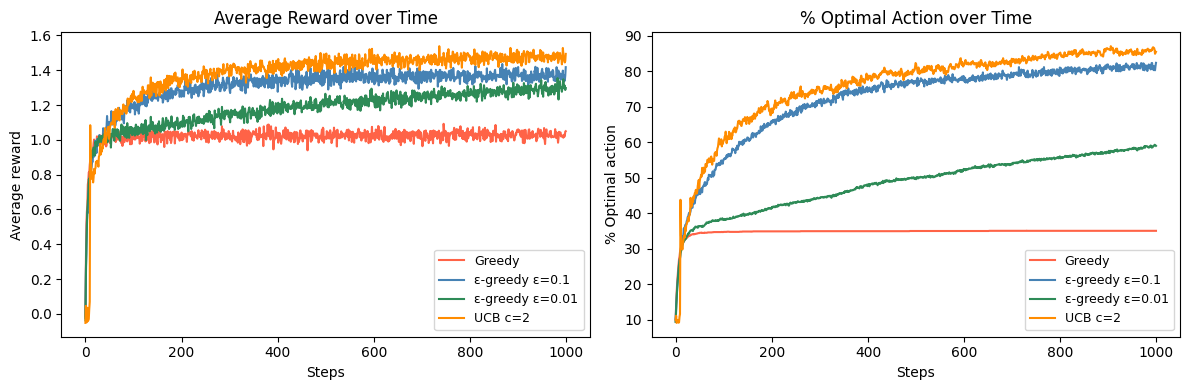

In [6]:
N_RUNS = 2000
N_STEPS = 1000

configs = [
    ('Greedy',         greedy,              'tomato'),
    ('ε-greedy ε=0.1', epsilon_greedy(0.1), 'steelblue'),
    ('ε-greedy ε=0.01',epsilon_greedy(0.01),'seagreen'),
    ('UCB c=2',        ucb(2),              'darkorange'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs:
    all_rewards   = np.zeros((N_RUNS, N_STEPS))
    all_optimal   = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = Bandit(n_arms=10)
        r, opt = run_agent(b, policy, N_STEPS)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Average Reward over Time'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('% Optimal Action over Time'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 4. Regret Analysis
Regret = total reward you *could* have earned (always playing optimal) minus what you actually earned.

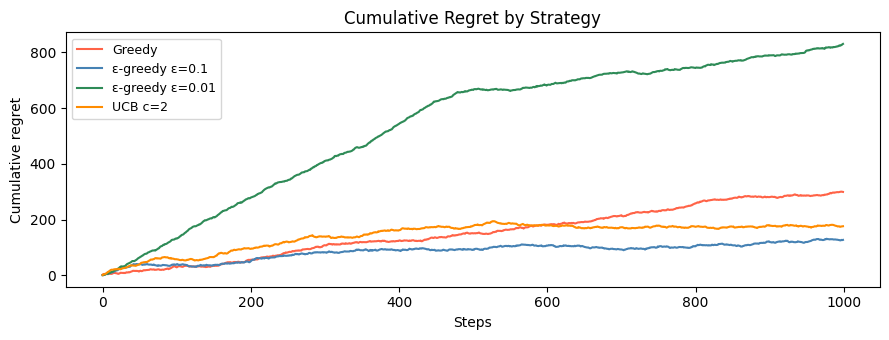

In [9]:
b = Bandit(n_arms=10)
best_mean = b.true_means.max()

plt.figure(figsize=(9, 3.5))
for label, policy, color in configs:
    b = Bandit(n_arms=10)
    # fix the same bandit for fair comparison
    b.true_means = np.array([0.2, -0.5, 1.2, 0.8, -0.1, 0.5, -0.8, 0.3, 1.5, 0.0])
    b.optimal_arm = np.argmax(b.true_means)
    best_mean = b.true_means.max()
    rewards, _ = run_agent(b, policy, N_STEPS)
    cumulative_regret = np.cumsum(best_mean - rewards)
    plt.plot(cumulative_regret, label=label, color=color, linewidth=1.5)
plt.xlabel('Steps'); plt.ylabel('Cumulative regret')
plt.title('Cumulative Regret by Strategy')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

## ✅ Exercises
1. Add a **softmax / Boltzmann** policy: pick arm proportionally to exp(Q/τ) where τ is temperature. Does it outperform ε-greedy?
2. What happens to UCB if you change c from 2 to 0.1 or 10? Re-run and plot.
3. **Challenge**: implement a **non-stationary** bandit where true means drift over time (add random noise each step). Which strategy handles this best?

1A) low temperature is same as greedy policy and high temperature leads to random .

In [10]:
def softmax(tau=1.0):
    def policy(Q, N, t):
        exp_Q = np.exp((Q - np.max(Q)) / tau) 
        probs = exp_Q / np.sum(exp_Q)
        return np.random.choice(len(Q), p=probs)
    return policy

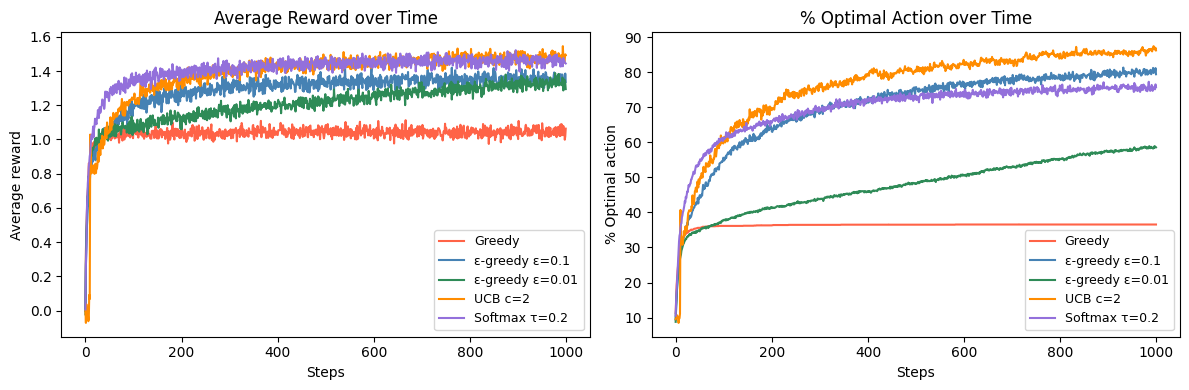

In [14]:
N_RUNS = 2000
N_STEPS = 1000

configs = [
    ('Greedy',         greedy,              'tomato'),
    ('ε-greedy ε=0.1', epsilon_greedy(0.1), 'steelblue'),
    ('ε-greedy ε=0.01',epsilon_greedy(0.01),'seagreen'),
    ('UCB c=2',        ucb(2),              'darkorange'),
    ('Softmax τ=0.2',  softmax(0.2),        'mediumpurple'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs:
    all_rewards   = np.zeros((N_RUNS, N_STEPS))
    all_optimal   = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = Bandit(n_arms=10)
        r, opt = run_agent(b, policy, N_STEPS)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Average Reward over Time'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('% Optimal Action over Time'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

2A)i re run the with the given values u can see tht exploitation is favored in c=0.1 .

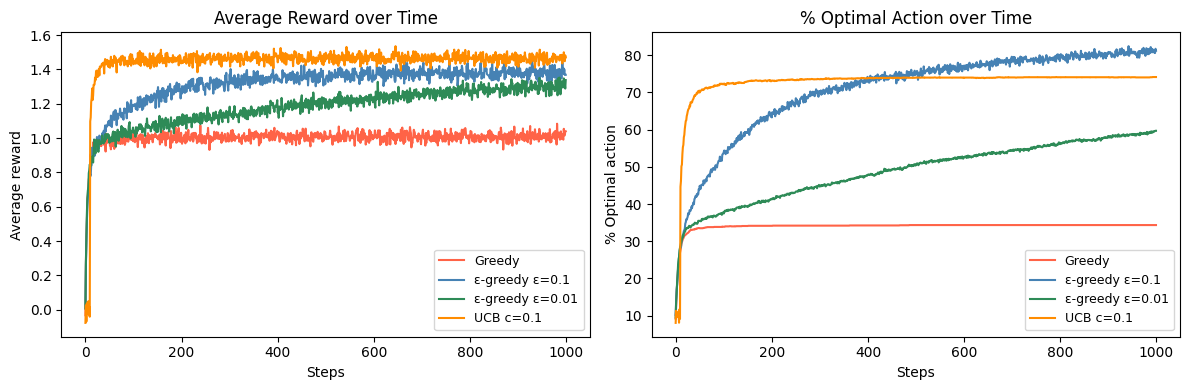

In [12]:
N_RUNS = 2000
N_STEPS = 1000

configs = [
    ('Greedy',         greedy,              'tomato'),
    ('ε-greedy ε=0.1', epsilon_greedy(0.1), 'steelblue'),
    ('ε-greedy ε=0.01',epsilon_greedy(0.01),'seagreen'),
    ('UCB c=0.1',        ucb(0.1),              'darkorange'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs:
    all_rewards   = np.zeros((N_RUNS, N_STEPS))
    all_optimal   = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = Bandit(n_arms=10)
        r, opt = run_agent(b, policy, N_STEPS)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Average Reward over Time'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('% Optimal Action over Time'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

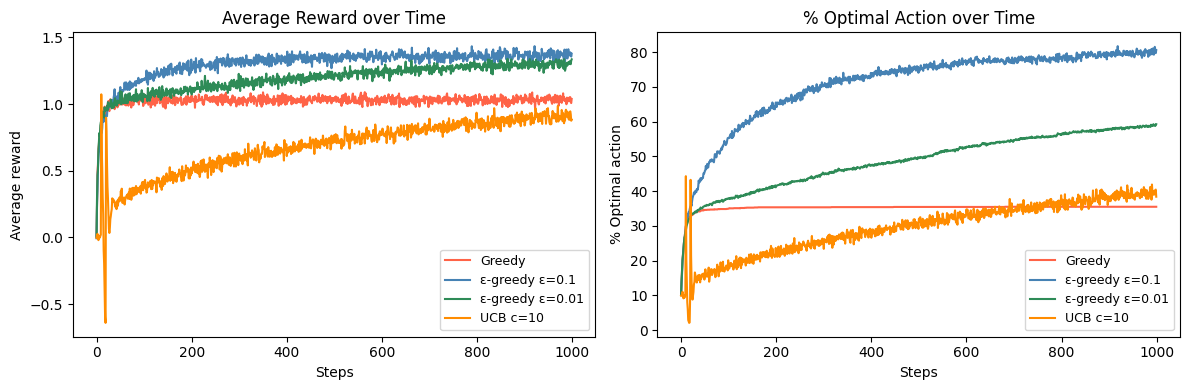

In [13]:
N_RUNS = 2000
N_STEPS = 1000

configs = [
    ('Greedy',         greedy,              'tomato'),
    ('ε-greedy ε=0.1', epsilon_greedy(0.1), 'steelblue'),
    ('ε-greedy ε=0.01',epsilon_greedy(0.01),'seagreen'),
    ('UCB c=10',        ucb(10),              'darkorange'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs:
    all_rewards   = np.zeros((N_RUNS, N_STEPS))
    all_optimal   = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = Bandit(n_arms=10)
        r, opt = run_agent(b, policy, N_STEPS)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Average Reward over Time'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('% Optimal Action over Time'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

3A)

In [15]:

class NonStationaryBandit:
    def __init__(self, n_arms=10):
        self.n_arms = n_arms
                self.true_means = np.zeros(n_arms) 
        self.optimal_arm = 0
    def pull(self, arm):
        self.true_means += np.random.normal(0, 0.01, self.n_arms)
        self.optimal_arm = np.argmax(self.true_means)
        return np.random.normal(self.true_means[arm], 1.0)


def run_non_stationary_agent(bandit, policy, n_steps=10000, alpha=None):
    n_arms = bandit.n_arms
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = []
    optimal_actions = []

    for t in range(n_steps):
        arm = policy(Q, N, t)
        reward = bandit.pull(arm)
        N[arm] += 1
        if alpha is None:
            Q[arm] += (reward - Q[arm]) / N[arm]
        else:
            Q[arm] += alpha * (reward - Q[arm])
            
        rewards.append(reward)
        optimal_actions.append(arm == bandit.optimal_arm)

    return np.array(rewards), np.array(optimal_actions)

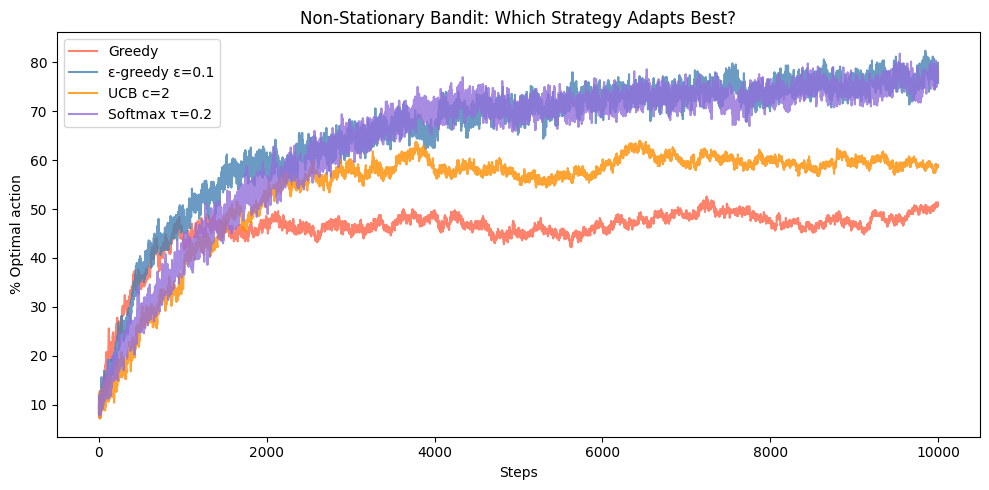

In [16]:
N_RUNS = 500
N_STEPS = 10000
ALPHA = 0.1  # We give all strategies the constant step-size so they can "forget" old data

# Ensure your configs list has all the strategies you want to test
configs = [
    ('Greedy',         greedy,              'tomato'),
    ('ε-greedy ε=0.1', epsilon_greedy(0.1), 'steelblue'),
    ('UCB c=2',        ucb(2),              'darkorange'),
    ('Softmax τ=0.2',  softmax(0.2),        'mediumpurple'), 
]

plt.figure(figsize=(10, 5))

for label, policy, color in configs:
    all_optimal = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = NonStationaryBandit(n_arms=10)
        # Run each strategy on the non-stationary environment
        _, opt = run_non_stationary_agent(b, policy, N_STEPS, alpha=ALPHA)
        all_optimal[run] = opt
        
    # Plot the smoothed rolling average for better visibility
    plt.plot(all_optimal.mean(axis=0) * 100, label=label, color=color, linewidth=1.5, alpha=0.8)

plt.xlabel('Steps')
plt.ylabel('% Optimal action')
plt.title('Non-Stationary Bandit: Which Strategy Adapts Best?')
plt.legend()
plt.tight_layout()
plt.show()

softmax and greedy did well